# 🏁 Gemini Model Benchmark — Punjabi STT
Compare **all Gemini models** on the same audio file across:
- ⏱ **Latency** (wall-clock seconds, real-time factor)
- 💰 **Cost** (per run and per hour of audio)
- 🔤 **Tokens** (prompt + output)
- 📝 **Transcript quality** (word count, character count, repetition/hallucination score)
- 📊 **WER / CER** (if a reference transcript is provided)
- 💾 **Saved outputs** — each model's transcript goes to its own Drive subfolder

> Run cells top-to-bottom. Everything is timed automatically.

In [1]:
%%capture
!pip install -q google-genai jiwer pydub librosa matplotlib pandas tabulate tqdm ipywidgets

import os, time, json, re
from collections import Counter
from google import genai
from google.colab import drive, userdata

## Step 1 — Mount Drive & Set Paths

In [2]:
try:
    drive.mount('/content/drive')
    print("✅ Google Drive mounted.")
except Exception as e:
    print(f"⚠ Drive mount: {e}")

# ── Audio source folder (same as used by the transcription notebook)
AUDIO_FOLDER = (
    "/content/drive/MyDrive/AnnamAI Tasks/"
    "Outreach Activity STT + Question Generation Workflow/"
    "Sample Audio Files"
)

# ── Base output folder (same structure: <base>/<audio_id>/<model_name>/)
OUTPUT_BASE = (
    "/content/drive/MyDrive/AnnamAI Tasks/"
    "Outreach Activity STT + Question Generation Workflow/"
    "Transcription Results"
)

# ── Optional: path to a reference transcript .txt for WER scoring
#    Set to None if you don't have one yet
REFERENCE_TRANSCRIPT_PATH = None

# ── List available audio files
files = sorted([f for f in os.listdir(AUDIO_FOLDER)
                if f.lower().endswith(('.m4a','.wav','.mp3','.ogg','.flac'))])
print(f"\nAudio files in folder ({len(files)} found):")
for i, f in enumerate(files):
    print(f"  [{i}] {f}")

Mounted at /content/drive
✅ Google Drive mounted.

Audio files in folder (5 found):
  [0] AUD-20260402-WA0018.m4a
  [1] Full Narration_MarauliKhurad.m4a
  [2] MarauliKhurad1.m4a
  [3] MarauliKhurad2.m4a
  [4] MarauliKhurad3.m4a


In [3]:
# ── Pick a file by index (change 0 to whichever number you want)
FILE_INDEX = 0  # @param {type:"integer"}

AUDIO_FILENAME = files[FILE_INDEX]
AUDIO_PATH     = os.path.join(AUDIO_FOLDER, AUDIO_FILENAME)
VIDEO_ID       = os.path.splitext(AUDIO_FILENAME)[0]

assert os.path.exists(AUDIO_PATH), f"File not found: {AUDIO_PATH}"
print(f"Selected : {AUDIO_FILENAME}")
print(f"Full path: {AUDIO_PATH}")
print(f"Video ID : {VIDEO_ID}")

Selected : AUD-20260402-WA0018.m4a
Full path: /content/drive/MyDrive/AnnamAI Tasks/Outreach Activity STT + Question Generation Workflow/Sample Audio Files/AUD-20260402-WA0018.m4a
Video ID : AUD-20260402-WA0018


## Step 2 — Measure Audio Duration

In [4]:
import librosa, numpy as np

audio, sr = librosa.load(AUDIO_PATH, sr=16000, mono=True)
DURATION_SEC = len(audio) / sr

print(f"Duration : {DURATION_SEC:.1f}s  ({DURATION_SEC/60:.2f} min)")
print(f"Samples  : {len(audio):,}  at {sr} Hz")

/tmp/ipykernel_1373/1458036522.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(AUDIO_PATH, sr=16000, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Duration : 883.3s  (14.72 min)
Samples  : 14,133,590  at 16000 Hz


## Step 3 — Load Reference Transcript (optional, for WER)

In [5]:
REFERENCE_TEXT = None

if REFERENCE_TRANSCRIPT_PATH and os.path.exists(REFERENCE_TRANSCRIPT_PATH):
    with open(REFERENCE_TRANSCRIPT_PATH, encoding='utf-8') as f:
        REFERENCE_TEXT = f.read().strip()
    print(f"✅ Reference loaded — {len(REFERENCE_TEXT):,} chars")
else:
    print("ℹ No reference transcript — WER/CER will show as '—'")

ℹ No reference transcript — WER/CER will show as '—'


## Step 4 — Initialise Gemini Client & Define Models

In [6]:
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
client = genai.Client(api_key=GEMINI_API_KEY)

# Quick connection test
_test = client.models.generate_content(model='gemini-2.5-flash', contents='ping')
print("✅ Gemini API connected.")

# ── All models to benchmark (add/remove as needed)
# Format: "display_name": {model_id, input $/1M tok, output $/1M tok}
MODELS = {
    "Gemini 2.5 Flash-Lite": {
        "model_id": "gemini-2.5-flash-lite",
        "input_usd_1m": 0.10, "output_usd_1m": 0.40,
        "generation": "2.5", "tier": "Cheapest API"
    },
    "Gemini 2.5 Flash": {
        "model_id": "gemini-2.5-flash",
        "input_usd_1m": 0.30, "output_usd_1m": 2.50,
        "generation": "2.5", "tier": "Your Current"
    },
    "Gemini 2.5 Pro": {
        "model_id": "gemini-2.5-pro",
        "input_usd_1m": 1.25, "output_usd_1m": 10.00,
        "generation": "2.5", "tier": "Premium"
    },
    "Gemini 3.1 Flash-Lite": {
        "model_id": "gemini-3.1-flash-lite",
        "input_usd_1m": 0.10, "output_usd_1m": 0.40,
        "generation": "3.1", "tier": "Cheapest"
    },
    "Gemini 3.1 Pro": {
        "model_id": "gemini-3.1-pro",
        "input_usd_1m": 2.00, "output_usd_1m": 12.00,
        "generation": "3.1", "tier": "Premium"
    },
    "Gemini 3.5 Flash": {
        "model_id": "gemini-3.5-flash",
        "input_usd_1m": 0.50, "output_usd_1m": 3.00,
        "generation": "3.5", "tier": "Frontier"
    },
}

print(f"\n{len(MODELS)} models queued for benchmarking:")
for name, cfg in MODELS.items():
    print(f"  • {name:30s}  [{cfg['model_id']}]  ${cfg['input_usd_1m']:.2f}/${ cfg['output_usd_1m']:.2f} per 1M tok")

✅ Gemini API connected.

6 models queued for benchmarking:
  • Gemini 2.5 Flash-Lite           [gemini-2.5-flash-lite]  $0.10/$0.40 per 1M tok
  • Gemini 2.5 Flash                [gemini-2.5-flash]  $0.30/$2.50 per 1M tok
  • Gemini 2.5 Pro                  [gemini-2.5-pro]  $1.25/$10.00 per 1M tok
  • Gemini 3.1 Flash-Lite           [gemini-3.1-flash-lite]  $0.10/$0.40 per 1M tok
  • Gemini 3.1 Pro                  [gemini-3.1-pro]  $2.00/$12.00 per 1M tok
  • Gemini 3.5 Flash                [gemini-3.5-flash]  $0.50/$3.00 per 1M tok


## Step 5 — Upload Audio to Gemini File API (once, reused for all models)

In [7]:
TRANSCRIPTION_PROMPT = (
    "Generate a verbatim, word-for-word transcript of this Punjabi audio. "
    "Attribute each speech turn to the correct speaker (e.g. SPEAKER_00, SPEAKER_01) "
    "and include timestamps in [MM:SS] format at the start of each line. "
    "Preserve all code-switching, dialect and colloquial expressions exactly as spoken. "
    "Output ONLY the transcript — no summaries, no commentary, no headers."
)

print(f"Uploading {AUDIO_FILENAME} to Gemini File API...")
t0 = time.perf_counter()
audio_file = client.files.upload(file=AUDIO_PATH)

# Wait for ACTIVE state
while True:
    info = client.files.get(name=audio_file.name)
    if info.state.name == "ACTIVE":
        break
    elif info.state.name == "FAILED":
        raise RuntimeError("Gemini File API processing failed.")
    time.sleep(3)

upload_time = time.perf_counter() - t0
print(f"✅ File ready in {upload_time:.1f}s  (file ID: {audio_file.name})")

Uploading AUD-20260402-WA0018.m4a to Gemini File API...
✅ File ready in 1.6s  (file ID: files/ub1ev7dxej7u)


## Step 6 — Run All Models & Record Metrics

In [8]:
def repetition_score(text):
    """4-gram repetition ratio — proxy for hallucination level."""
    if not text or len(text.split()) < 8:
        return 0.0
    words = text.split()
    ngrams = [' '.join(words[i:i+4]) for i in range(len(words)-3)]
    if not ngrams:
        return 0.0
    repeated = sum(1 for _, c in Counter(ngrams).items() if c > 1)
    return repeated / len(ngrams)

results = []

print(f"\nBenchmarking {len(MODELS)} models on '{AUDIO_FILENAME}' ({DURATION_SEC:.0f}s audio)\n")
print(f"{'Model':<28} {'Latency':>9} {'RTF':>6} {'Tokens':>8} {'Cost/run':>10} {'Cost/hr':>9} {'Rep':>6}")
print("─" * 85)

for name, cfg in MODELS.items():
    try:
        t_start = time.perf_counter()
        response = client.models.generate_content(
            model=cfg["model_id"],
            contents=[TRANSCRIPTION_PROMPT, audio_file]
        )
        latency = time.perf_counter() - t_start

        transcript = response.text.strip() if response.text else ""

        # Token counts
        um = getattr(response, 'usage_metadata', None)
        in_tok  = getattr(um, 'prompt_token_count', 0) or 0
        out_tok = getattr(um, 'candidates_token_count', 0) or 0
        tot_tok = getattr(um, 'total_token_count', 0) or (in_tok + out_tok)

        # Cost
        cost_run = (in_tok / 1e6) * cfg["input_usd_1m"] + (out_tok / 1e6) * cfg["output_usd_1m"]
        cost_hr  = (cost_run / DURATION_SEC) * 3600 if DURATION_SEC > 0 else 0

        # Quality
        rtf      = latency / DURATION_SEC if DURATION_SEC > 0 else 0
        lat_pm   = latency / (DURATION_SEC / 60) if DURATION_SEC > 0 else 0  # sec per min of audio
        rep      = repetition_score(transcript)
        wc       = len(transcript.split())
        cc       = len(transcript)

        # WER / CER
        wer_val = cer_val = None
        if REFERENCE_TEXT and transcript:
            try:
                from jiwer import wer, cer
                wer_val = wer(REFERENCE_TEXT, transcript)
                cer_val = cer(REFERENCE_TEXT, transcript)
            except Exception:
                pass

        r = {
            "model_name":   name,
            "model_id":     cfg["model_id"],
            "generation":   cfg["generation"],
            "tier":         cfg["tier"],
            "transcript":   transcript,
            "latency_sec":  round(latency, 2),
            "rtf":          round(rtf, 3),
            "lat_per_min":  round(lat_pm, 2),
            "in_tokens":    in_tok,
            "out_tokens":   out_tok,
            "total_tokens": tot_tok,
            "cost_run_usd": round(cost_run, 6),
            "cost_hr_usd":  round(cost_hr, 4),
            "rep_score":    round(rep, 4),
            "word_count":   wc,
            "char_count":   cc,
            "wer":          round(wer_val, 4) if wer_val is not None else None,
            "cer":          round(cer_val, 4) if cer_val is not None else None,
            "audio_file":   AUDIO_FILENAME,
            "duration_sec": round(DURATION_SEC, 1),
            "error":        None,
        }
        results.append(r)

        print(f"{name:<28} {latency:>8.1f}s {rtf:>5.2f}x {tot_tok:>8,} ${cost_run:>9.5f} ${cost_hr:>8.4f} {rep:>6.3f}")

    except Exception as e:
        err = str(e)[:120]
        print(f"{name:<28} ✗ FAILED: {err}")
        results.append({
            "model_name": name, "model_id": cfg["model_id"],
            "generation": cfg["generation"], "tier": cfg["tier"],
            "transcript": "", "latency_sec": 0, "rtf": 0, "lat_per_min": 0,
            "in_tokens": 0, "out_tokens": 0, "total_tokens": 0,
            "cost_run_usd": 0, "cost_hr_usd": 0, "rep_score": 0,
            "word_count": 0, "char_count": 0, "wer": None, "cer": None,
            "audio_file": AUDIO_FILENAME, "duration_sec": round(DURATION_SEC, 1),
            "error": err,
        })

print("─" * 85)
print(f"Done. {len([r for r in results if not r['error']])} succeeded, {len([r for r in results if r['error']])} failed.")


Benchmarking 6 models on 'AUD-20260402-WA0018.m4a' (883s audio)

Model                          Latency    RTF   Tokens   Cost/run   Cost/hr    Rep
─────────────────────────────────────────────────────────────────────────────────────
Gemini 2.5 Flash-Lite        ✗ FAILED: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand 
Gemini 2.5 Flash                 74.7s  0.08x   45,447 $  0.03460 $  0.1410  0.022
Gemini 2.5 Pro               ✗ FAILED: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and 
Gemini 3.1 Flash-Lite            40.4s  0.05x   29,782 $  0.00526 $  0.0214  0.011
Gemini 3.1 Pro               ✗ FAILED: 404 NOT_FOUND. {'error': {'code': 404, 'message': 'models/gemini-3.1-pro is not found for API version v1beta, or is not 
Gemini 3.5 Flash                 92.6s  0.10x   44,451 $  0.04181 $  0.1704  0.014
────────────────────────────────────

## Step 7 — Save Transcripts to Per-Model Drive Folders

In [9]:
saved_paths = {}

for r in results:
    if not r["transcript"]:
        continue

    model_folder = r["model_id"].replace("/", "_").replace(":", "_")
    folder = os.path.join(OUTPUT_BASE, VIDEO_ID, model_folder)
    os.makedirs(folder, exist_ok=True)

    # transcript .txt
    tx_path = os.path.join(folder, f"{VIDEO_ID.lower()}_transcript.txt")
    with open(tx_path, "w", encoding="utf-8") as f:
        f.write(r["transcript"])

    # metrics sidecar .json
    meta = {k: v for k, v in r.items() if k != "transcript"}
    meta_path = os.path.join(folder, f"{VIDEO_ID.lower()}_metrics.json")
    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2, ensure_ascii=False)

    saved_paths[r["model_name"]] = folder
    print(f"✅ {r['model_name']:28s} → {folder}")

✅ Gemini 2.5 Flash             → /content/drive/MyDrive/AnnamAI Tasks/Outreach Activity STT + Question Generation Workflow/Transcription Results/AUD-20260402-WA0018/gemini-2.5-flash
✅ Gemini 3.1 Flash-Lite        → /content/drive/MyDrive/AnnamAI Tasks/Outreach Activity STT + Question Generation Workflow/Transcription Results/AUD-20260402-WA0018/gemini-3.1-flash-lite
✅ Gemini 3.5 Flash             → /content/drive/MyDrive/AnnamAI Tasks/Outreach Activity STT + Question Generation Workflow/Transcription Results/AUD-20260402-WA0018/gemini-3.5-flash


## Step 8 — Comparison Table

In [10]:
import pandas as pd
from IPython.display import display, HTML

rows = []
for r in results:
    rows.append({
        "Model":        r["model_name"],
        "Gen":          r["generation"],
        "Tier":         r["tier"],
        "Latency (s)":  r["latency_sec"] if not r["error"] else "FAILED",
        "RTF":          f"{r['rtf']:.2f}×" if not r["error"] else "—",
        "s/min audio":  f"{r['lat_per_min']:.1f}" if not r["error"] else "—",
        "In Tok":       f"{r['in_tokens']:,}"  if not r["error"] else "—",
        "Out Tok":      f"{r['out_tokens']:,}" if not r["error"] else "—",
        "Cost/run $":   f"{r['cost_run_usd']:.5f}" if not r["error"] else "—",
        "Cost/hr $":    f"{r['cost_hr_usd']:.4f}"  if not r["error"] else "—",
        "Words":        r["word_count"]  if not r["error"] else "—",
        "Rep ↓":        f"{r['rep_score']:.3f}" if not r["error"] else "—",
        "WER ↓":        f"{r['wer']:.2%}" if r["wer"] is not None else "—",
        "CER ↓":        f"{r['cer']:.2%}" if r["cer"] is not None else "—",
    })

df = pd.DataFrame(rows)
pd.set_option('display.max_colwidth', 35)
pd.set_option('display.width', 200)

print("\n═══════════════════ BENCHMARK RESULTS ═══════════════════")
print(f"Audio  : {AUDIO_FILENAME}  ({DURATION_SEC:.0f}s / {DURATION_SEC/60:.1f}min)")
print(f"Models : {len(results)}  |  Reference: {'Provided' if REFERENCE_TEXT else 'Not provided (WER = —)'}")
print("═" * 60)
display(df)


═══════════════════ BENCHMARK RESULTS ═══════════════════
Audio  : AUD-20260402-WA0018.m4a  (883s / 14.7min)
Models : 6  |  Reference: Not provided (WER = —)
════════════════════════════════════════════════════════════


,Model,Gen,Tier,Latency (s),RTF,s/min audio,In Tok,Out Tok,Cost/run $,Cost/hr $,Words,Rep ↓,WER ↓,CER ↓
0,Gemini 2.5 Flash-Lite,2.5,Cheapest API,FAILED,—,—,—,—,—,—,—,—,—,—
1,Gemini 2.5 Flash,2.5,Your Current,74.73,0.09×,5.1,"28,367","10,437",0.03460,0.1410,3504,0.022,—,—
2,Gemini 2.5 Pro,2.5,Premium,FAILED,—,—,—,—,—,—,—,—,—,—
3,Gemini 3.1 Flash-Lite,3.1,Cheapest,40.44,0.05×,2.8,"22,168","7,614",0.00526,0.0214,3041,0.011,—,—
4,Gemini 3.1 Pro,3.1,Premium,FAILED,—,—,—,—,—,—,—,—,—,—
5,Gemini 3.5 Flash,3.5,Frontier,92.62,0.10×,6.3,"22,168","10,241",0.04181,0.1704,3569,0.014,—,—


## Step 9 — Charts

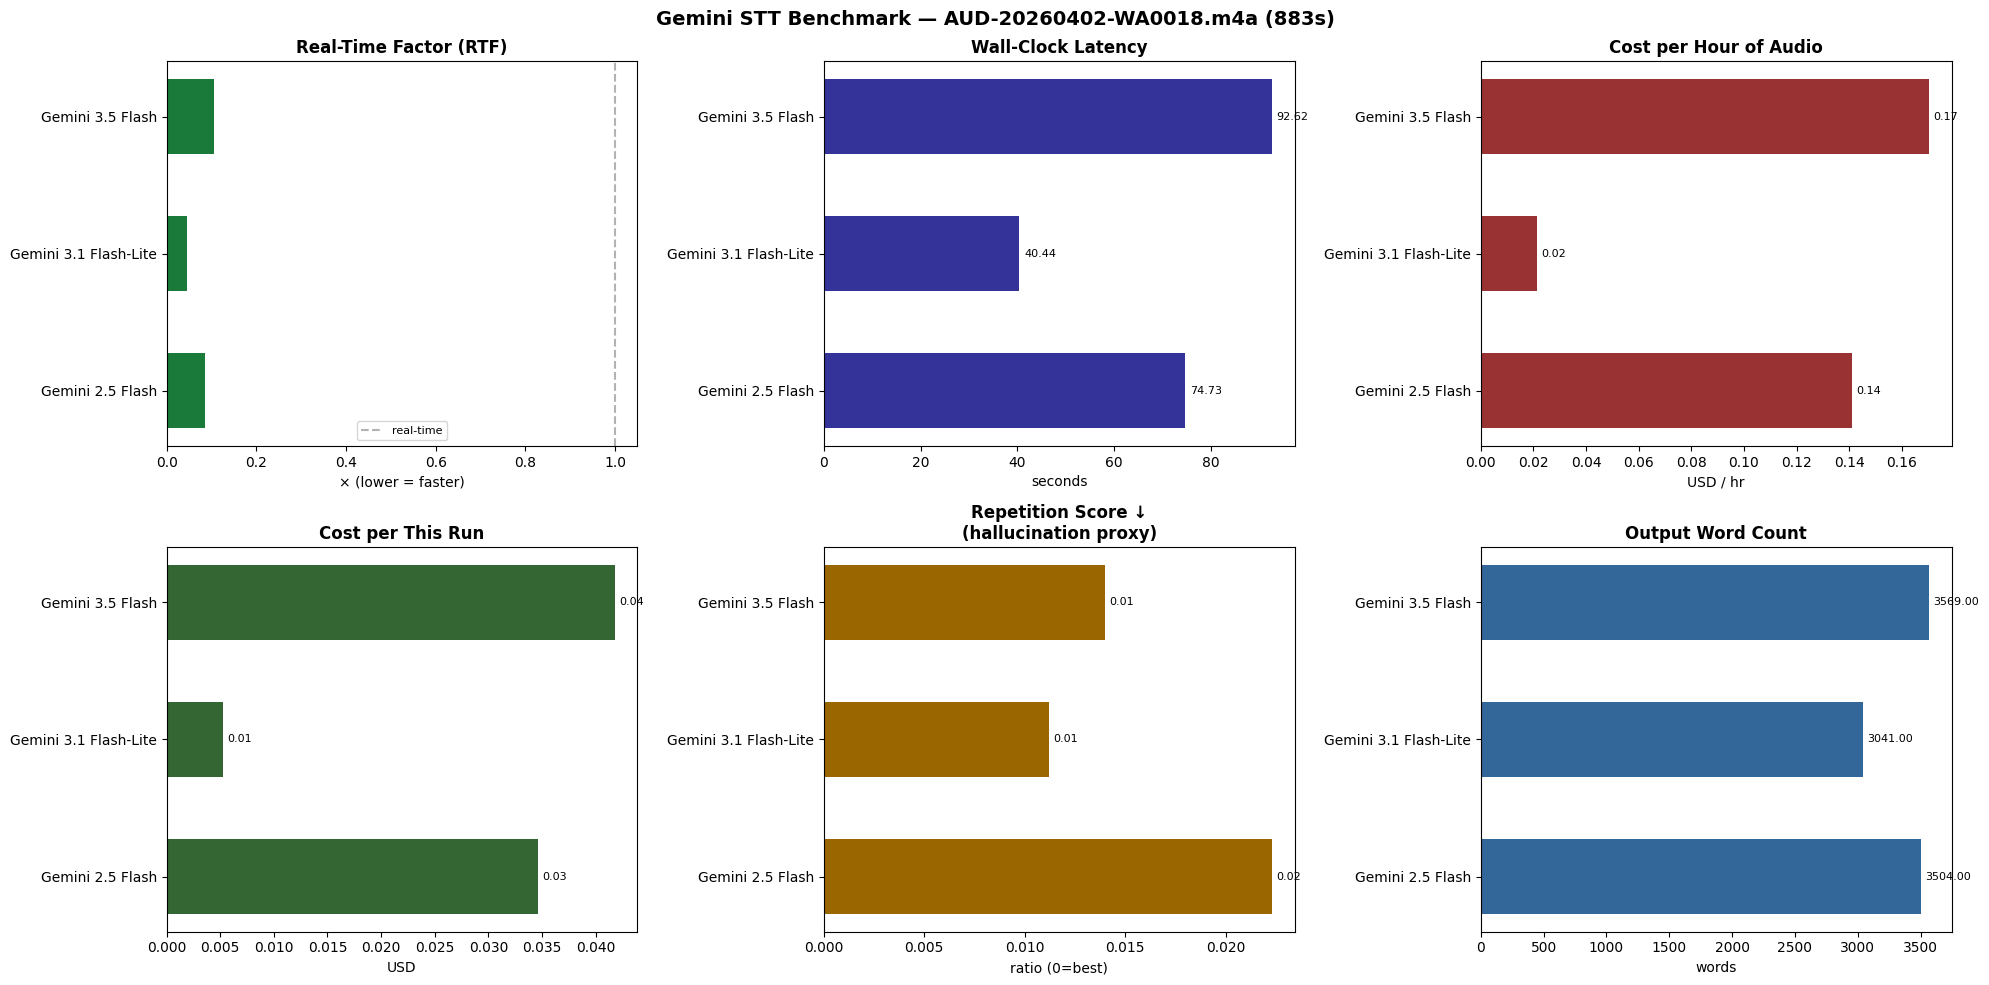

Chart saved to /tmp/AUD-20260402-WA0018_benchmark.png


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

ok = [r for r in results if not r["error"] and r["latency_sec"] > 0]
if not ok:
    print("No successful runs to plot.")
else:
    names    = [r["model_name"] for r in ok]
    latency  = [r["latency_sec"] for r in ok]
    rtf      = [r["rtf"] for r in ok]
    cost_hr  = [r["cost_hr_usd"] for r in ok]
    cost_run = [r["cost_run_usd"] for r in ok]
    rep      = [r["rep_score"] for r in ok]
    words    = [r["word_count"] for r in ok]

    fig, axes = plt.subplots(2, 3, figsize=(20, 10))
    fig.suptitle(f"Gemini STT Benchmark — {AUDIO_FILENAME} ({DURATION_SEC:.0f}s)", fontsize=14, fontweight="bold")

    def hbar(ax, vals, title, xlabel, color="#222222", ref_line=None):
        bars = ax.barh(names, vals, color=color, height=0.55)
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel(xlabel)
        if ref_line is not None:
            ax.axvline(ref_line, color="gray", linestyle="--", alpha=0.6, label=f"ref = {ref_line}")
            ax.legend(fontsize=8)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_width() + max(vals)*0.01, bar.get_y() + bar.get_height()/2,
                    f"{val:.2f}", va="center", fontsize=8)

    # RTF colors
    rtf_colors = ["#1a7a3a" if v < 1 else "#b8860b" if v < 3 else "#b22222" for v in rtf]
    axes[0][0].barh(names, rtf, color=rtf_colors, height=0.55)
    axes[0][0].axvline(1.0, color="gray", linestyle="--", alpha=0.6, label="real-time")
    axes[0][0].set_title("Real-Time Factor (RTF)", fontweight="bold")
    axes[0][0].set_xlabel("× (lower = faster)")
    axes[0][0].legend(fontsize=8)

    hbar(axes[0][1], latency,  "Wall-Clock Latency",  "seconds", "#333399")
    hbar(axes[0][2], cost_hr,  "Cost per Hour of Audio", "USD / hr", "#993333")
    hbar(axes[1][0], cost_run, "Cost per This Run",    "USD",     "#336633")
    hbar(axes[1][1], rep,      "Repetition Score ↓\n(hallucination proxy)", "ratio (0=best)", "#996600")
    hbar(axes[1][2], words,    "Output Word Count",    "words",   "#336699")

    plt.tight_layout()
    plt.savefig(f"/tmp/{VIDEO_ID}_benchmark.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Chart saved to /tmp/{VIDEO_ID}_benchmark.png")

## Step 10 — Side-by-Side Transcript Preview

In [12]:
print("═" * 70)
print("TRANSCRIPT PREVIEW (first 400 chars per model)")
print("═" * 70)

if REFERENCE_TEXT:
    print("── REFERENCE ──")
    print(REFERENCE_TEXT[:400])
    print()

for r in results:
    if r["transcript"]:
        wer_str = f"  WER={r['wer']:.2%}" if r["wer"] is not None else ""
        print(f"── {r['model_name']} (RTF={r['rtf']:.2f}×  ${r['cost_run_usd']:.5f}/run{wer_str})")
        print(r["transcript"][:400])
        print()

══════════════════════════════════════════════════════════════════════
TRANSCRIPT PREVIEW (first 400 chars per model)
══════════════════════════════════════════════════════════════════════
── Gemini 2.5 Flash (RTF=0.09×  $0.03460/run)
[00:00] SPEAKER_00: ਹਾਂਜੀ ਸਤਿ ਸ਼੍ਰੀ ਅਕਾਲ ਜੀ। ਮੇਰਾ ਨਾਮ ਅੰਮ੍ਰਿਤਪ੍ਰੀਤ ਸਿੰਘ ਆ ਜੀ। ਪਿੰਡ ਮੇਰਾ ਮਨਸੂਹਾ ਕਲਾਂ ਜੀ। ਤੇ ਪਿੰਡ ਮੇਰਾ ਮਨਸੂਹਾ ਕਲਾਂ ਜੀ।
[00:00] SPEAKER_00: ਮਨਸੂਹਾ।
[00:01] SPEAKER_01: ਮਨਸੂਹਾ।
[00:02] SPEAKER_00: ਹਾਂਜੀ।
[00:02] SPEAKER_01: ਠੀਕ ਆ।
[00:02] SPEAKER_00: ਤੇ ਮੈਂ ਰੋਪੜ
[00:02] SPEAKER_01: ਅੰਮ੍ਰਿਤਸਰ ਤੋਂ ਆਏ ਆਂ।
[00:03] SPEAKER_00: ਅੱਛਾ ਜੀ। ਅੱਛਾ ਅੱਛਾ ਜੀ।
[00:03] SPEAKER_01: ਰੋਪੜ ਤੋਂ ਆਏ ਹੋ।
[00:0

── Gemini 3.1 Flash-Lite (RTF=0.05×  $0.00526/run)
[00:00] ਹਾਂ ਜੀ ਸਤਿ ਸ਼੍ਰੀ ਅਕਾਲ ਜੀ। ਮੇਰਾ ਨਾਮ ਅੰਮ੍ਰਿਤਪ੍ਰੀਤ ਸਿੰਘ ਹੈ ਜੀ। ਪਿੰਡ ਮੇਰਾ ਮਨਸੂਹਾ ਕਲਾ ਹੈ ਜੀ, ਤੇ ਪਿੰਡ ਮੇਰਾ ਮਨਸੂਹਾ ਕਲਾ ਹੈ ਜੀ।
[00:07] ਮਨਸੂਹਾ।
[00:08] ਮਨਸੂਹਾ?
[00:08] ਹਾਂ ਜੀ, ਤੇ ਮੈਂ ਰੋਪੜ ਜੋਬ ਅੱਛਾ ਜੀ।
[00:15] ਅੱਛਾ ਅੱਛਾ ਜੀ।
[00:16] ਤੇ ਮੈਂ ਜੀ ਰੋਪੜ ਆਈ ਆਈ ਟੀ ਵਿੱਚ ਜੋਬ ਕਰਦਾ ਜੀ। ਸਾਡਾ ਆਈ ਆਈ ਟੀ ਵਿੱਚ ਡਿਪਾਰਟਮੈਂਟ ਹੈ ਜੀ ਅਨਮ 

## Step 11 — Export Consolidated Results to Drive

In [13]:
RESULTS_FOLDER = os.path.join(OUTPUT_BASE, VIDEO_ID, "_benchmark_summary")
os.makedirs(RESULTS_FOLDER, exist_ok=True)

# CSV (without full transcript to keep it readable)
rows_export = [{k: v for k, v in r.items() if k != "transcript"} for r in results]
df_export = pd.DataFrame(rows_export)
csv_path = os.path.join(RESULTS_FOLDER, f"{VIDEO_ID}_benchmark.csv")
df_export.to_csv(csv_path, index=False)
print(f"✅ CSV  → {csv_path}")

# Full JSON (includes transcripts)
json_path = os.path.join(RESULTS_FOLDER, f"{VIDEO_ID}_benchmark_full.json")
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)
print(f"✅ JSON → {json_path}")

# Chart PNG
import shutil
chart_src = f"/tmp/{VIDEO_ID}_benchmark.png"
if os.path.exists(chart_src):
    chart_dst = os.path.join(RESULTS_FOLDER, f"{VIDEO_ID}_benchmark_chart.png")
    shutil.copy(chart_src, chart_dst)
    print(f"✅ Chart → {chart_dst}")

print(f"\n📁 Summary folder: {RESULTS_FOLDER}")

✅ CSV  → /content/drive/MyDrive/AnnamAI Tasks/Outreach Activity STT + Question Generation Workflow/Transcription Results/AUD-20260402-WA0018/_benchmark_summary/AUD-20260402-WA0018_benchmark.csv
✅ JSON → /content/drive/MyDrive/AnnamAI Tasks/Outreach Activity STT + Question Generation Workflow/Transcription Results/AUD-20260402-WA0018/_benchmark_summary/AUD-20260402-WA0018_benchmark_full.json
✅ Chart → /content/drive/MyDrive/AnnamAI Tasks/Outreach Activity STT + Question Generation Workflow/Transcription Results/AUD-20260402-WA0018/_benchmark_summary/AUD-20260402-WA0018_benchmark_chart.png

📁 Summary folder: /content/drive/MyDrive/AnnamAI Tasks/Outreach Activity STT + Question Generation Workflow/Transcription Results/AUD-20260402-WA0018/_benchmark_summary


---
## Notes
- **RTF < 1×** = faster than real-time (green). **RTF 1–3×** = acceptable (amber). **RTF > 3×** = slow (red).
- **Rep Score** = 4-gram repetition ratio. 0 = no loops. >0.1 = possible hallucination.
- **WER / CER** only appear if you set `REFERENCE_TRANSCRIPT_PATH` to a verified ground-truth `.txt` file.
- Each model's transcript + metrics JSON is saved in: `Transcription Results/<audio_id>/<model_id>/`
- The `_benchmark_summary/` folder contains the consolidated CSV, full JSON, and chart.